# Detección de Tumores Cerebrales con Ultralytics YOLO26

En este cuaderno exploraremos cómo la Inteligencia Artificial, y en particular el modelo **YOLO26**, está transformando el diagnóstico médico por imagen. Desarrollado por [Ultralytics](https://ultralytics.com), YOLO es el estándar actual en detección de objetos en tiempo real.

Este material está diseñado para proporcionar una visión completa: desde el valor estratégico y clínico para perfiles directivos (C-level) y médicos, hasta la implementación técnica para equipos de desarrollo, con un enfoque práctico para pro
fesionales de la salud, directivos y desarrolladores

Referencias:
* [YOLO DETECTION](https://docs.ultralytics.com/tasks/detect/)

* [Brain Tumor Exmaple](https://github.com/ultralytics/notebooks/blob/main/notebooks/how-to-train-ultralytics-yolo-on-brain-tumor-detection-dataset.ipynb)

## 1. Introducción a YOLO y Ultralytics

### ¿Qué es YOLO?
**YOLO** (*You Only Look Once* - "Solo miras una vez") es una revolucionaria arquitectura de Inteligencia Artificial especializada en la **visión por computadora**. A diferencia de modelos anteriores que escaneaban una imagen en múltiples pasos, YOLO analiza la imagen completa en una única pasada, logrando una velocidad y precisión inigualables. Esto lo hace ideal para entornos médicos donde el tiempo y la exactitud son críticos.

**YOLO**  fue desarrollado por Joseph Redmon y Ali Farhadi en la Universidad de Washington. Lanzado en 2015, YOLO ganó popularidad por su alta velocidad y precisión. En su version YOLOv8, lanzada en 2023, el mantenimiento y evolucion de este modelo fue retomado por Ultralytics.

### ¿Qué es Ultralytics?
**Ultralytics** es la empresa y la comunidad de código abierto detrás del desarrollo de las versiones más modernas de YOLO (como YOLOv8 y YOLO26). Han democratizado el acceso a esta tecnología mediante librerías accesibles en Python, ocultando la complejidad matemática subyacente y permitiendo a las organizaciones centrarse en resolver sus problemas de negocio y salud.

### ¿Por qué son útiles en el sector salud?
La capacidad de detectar anomalías (como tumores, fracturas o lesiones) en tiempo real sobre imágenes radiológicas (resonancias magnéticas, tomografías, rayos X) reduce drásticamente la carga de trabajo de los especialistas, disminuye el error humano por fatiga y acelera el triaje de pacientes críticos. Con Ultralytics, un equipo de desarrollo puede entrenar un modelo a medida en días en lugar de meses, acelerando la innovación en el entorno clínico.

## 2. El Caso Médico: Detección de Tumores Cerebrales

En este ejercicio nos enfrentamos a un reto real y de gran impacto: **la automatización en la detección de tumores cerebrales a partir de imágenes de Resonancia Magnética (RM)**.

### Contexto Clínico
La identificación temprana y precisa de los límites de un tumor cerebral es un paso fundamental para la planificación quirúrgica y el seguimiento oncológico. Tradicionalmente, esta es una tarea manual, laboriosa y dependiente de la experiencia del radiólogo.

### Nuestro Enfoque Técnico
A lo largo de este *notebook*, desarrollaremos el flujo completo de un proyecto de IA:
1. **Preparación de Datos:** Exploraremos cómo se organiza un conjunto de datos (*dataset*) de imágenes de RM, diferenciando casos positivos (con tumor) de negativos.
2. **Entrenamiento:** Instruiremos al modelo YOLO26 para que aprenda a identificar los patrones visuales que caracterizan a los tumores.
3. **Predicción e Inferencia:** Pondremos a prueba nuestro modelo con imágenes nuevas para evaluar su capacidad de detección en un escenario "real".
4. **Exportación:** Prepararemos el modelo final para que los desarrolladores puedan integrarlo en los sistemas de información hospitalaria (HIS) o herramientas PACS.

## 3. Estructura del Dataset

Para que la IA aprenda, necesitamos proporcionarle ejemplos. Nuestro conjunto de datos de tumores cerebrales está rigurosamente dividido en dos subconjuntos para garantizar una evaluación justa y científica:

- **Conjunto de Entrenamiento (*Training set*):** Contiene **893 imágenes** médicas. Cada imagen está acompañada de anotaciones precisas (coordenadas) que señalan dónde se encuentra el tumor. El modelo usa estos datos para "estudiar".
- **Conjunto de Validación/Prueba (*Testing set*):** Compuesto por **223 imágenes**. Este conjunto permanece oculto durante el entrenamiento y se usa como examen final para comprobar si el modelo realmente ha aprendido a generalizar o si solo memorizó las imágenes anteriores.

## 4. Aplicaciones Clínicas

El uso de herramientas de visión artificial como YOLO en la detección de tumores no busca reemplazar al médico, sino potenciar sus capacidades (*Inteligencia Aumentada*). Sus principales aplicaciones incluyen:

- **Diagnóstico Precoz:** Detección de anomalías en estadios tempranos que podrían pasar desapercibidas para el ojo humano.
- **Planificación Quirúrgica:** Delimitación exacta (segmentación/detección) de las masas tumorales para guiar intervenciones quirúrgicas o radioterapia.
- **Monitorización:** Evaluación objetiva y automatizada de cómo evoluciona el tamaño de un tumor en respuesta a un tratamiento a lo largo del tiempo.

## 5. Configuración del Entorno (*Setup*)

Antes de comenzar, debemos preparar el entorno de ejecución instalando la librería `ultralytics` y sus dependencias. El siguiente bloque de código realiza la instalación y verifica que tanto el software como el hardware (incluyendo el acceso a la GPU, fundamental para la velocidad del Deep Learning) estén listos y operativos.

In [2]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)


## 6. Archivo de Configuración del Dataset (YAML)

Para que YOLO sepa dónde buscar las imágenes y cuántos tipos de anomalías debe detectar, utilizamos un archivo de configuración en formato **YAML**.

En este caso, definimos dos clases o categorías principales:
- `0: negative` (Imagen sin tumor)
- `1: positive` (Imagen con tumor)

A continuación se muestra el contenido del archivo de configuración `brain-tumor.yaml` que debemos de dejar en el directorio de trabajo desde el que iniciaremos el entrenamiento.

Crea un fichero llamado `brain-tumor.yaml` en el directorio donde se descargo el modelo `yolo26n.pt` con el siguiente contenido:

```yaml
# Ultralytics YOLO 🚀, licencia AGPL-3.0
# Dataset de Tumores Cerebrales por Ultralytics
# Documentación: https://docs.ultralytics.com/datasets/detect/brain-tumor/
# Ejemplo de uso: yolo train data=brain-tumor.yaml
# parent
# ├── ultralytics
# └── datasets
#     └── brain-tumor  ← downloads here (4.21 MB)

# Conjuntos de Train/val/test
path: brain-tumor # directorio raíz del dataset
train: images/train # imágenes de entrenamiento 893 imágenes
val: images/val # imágenes de validación 223 imágenes

# Clases (Etiquetas que el modelo va a predecir)
names:
  0: negative # Negativo (sin tumor)
  1: positive # Positivo (con tumor)

# URL de descarga (opcional)
download: https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip
```

## 7. Entrenamiento del Modelo (*Train*)

Este es el núcleo tecnológico del proceso. Durante el entrenamiento, le mostramos a la red neuronal los cientos de imágenes médicas junto con sus respuestas correctas. El modelo ajustará millones de parámetros internos matemáticamente hasta aprender a identificar las firmas visuales de un tumor.

En el código a continuación, inicializamos un modelo pre-entrenado (`yolo26n.pt`) y lo ajustamos a nuestro dataset específico durante **10 épocas** (iteraciones completas sobre todos los datos). En entornos productivos, este proceso puede durar desde horas hasta días.

In [4]:
from ultralytics import YOLO

# Cargar un modelo base de tamaño nano (se recomienda usar un modelo pre-entrenado para hacer ajuste fino)
model = YOLO("yolo26n.pt")

# Entrenar el modelo -> copiar "brain-tumor.yaml" en el path de ejecución
results = model.train(
    data="brain-tumor.yaml", # especificaciones del data set entrenamiento y validacion
    epochs=10,               # Número de veces que el modelo ve todo el dataset, más aprendizaje (pero riesgo de overfitting)
    imgsz=640                # Tamaño de la imagen de entrada (640x640)
    )

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

Interpretacion de los resultados:

* Resumen general del modelo
  * 122 capas, ~2.37M parámetros → modelo pequeño (tipo nano, rápido pero menos potente)
  * 5.2 GFLOPs → bajo costo computacional (bueno para tiempo real)

  En un modelo ligero, por lo que se sacrifica precisión por velocidad.

* Métricas principales:
  * Precision (P): De los objetos que predijo tu modelo, ¿cuántos fueron correctos? Solo 45.6% de las detecciones son correctas. Hay bastantes falsos positivos. **El modelo “ve cosas que no existen” con cierta frecuencia**
  * Recall (R) Exhaustividad: 0.704 De los objetos reales, ¿cuántos detectó tu modelo?, Detecta 70.4% de los objetos reales. Hay pocos falsos negativos. ** Bastante bueno: no se le escapan demasiados objetos**
  * mAP@0.5:       0.467. Calidad general aceptable pero media-baja. **Detecta objetos, pero no de forma muy fiable**.
→ modelo detecta mucho, pero se equivoca bastante
  * mAP@0.5:0.95:  0.324. Métrica más estricta (localización precisa). Resultado bajo, las cajas no están muy bien ajustadas, **Detecta el objeto, pero la bounding box no es precisa**

En general vemos que el modelo está “sobre-detectando”:
* Encuentra la mayoría de objetos (recall OK)
* Pero se equivoca bastante (precision baja)
* Y no localiza con precisión (mAP50-95 bajo)

Si el dataset es pequeño, esta desbalanceado (menos muestras positivas y esa clase se predice peor) se limita la capacidad del aprendizaje. El tamaño del modelo tambien limita la capacidad del aprendizaje.

El modelo entrenado es un buen detector “explorador” (encuentra cosas) pero es malo “decidiendo” (muchos falsos positivos) y peor en la clase positiva

Veamos algunos ejemplos de deteccion de este modelo:

![Ejemplo del conjunto de datos de tumores cerebrales](https://github.com/ultralytics/docs/releases/download/0/brain-tumor-dataset-sample-image.avif)

## 8. Predicción e Inferencia (*Predict*)

Una vez que nuestro modelo ha sido entrenado y ha "aprendido" a reconocer tumores, pasamos a la fase de **Inferencia**. En este paso, le entregamos al modelo imágenes clínicas completamente nuevas para que emita un diagnóstico.

Usaremos una imagen de las que tenemos en el conjunto de datos de validacion, puesto que las imágenes de validación NO se usan para entrenar el modelo solo para evaluar la evolucion del entrenamiento.

Cargamos los mejores pesos matemáticos obtenidos durante el entrenamiento (`best.pt`) y evaluamos la imagen proporcionada. El modelo generará una nueva imagen con el cuadro delimitador (bounding box) sobre el tumor detectado.

In [15]:
from ultralytics import YOLO

# Cargar el modelo ya entrenado (los mejores pesos)
modelp = YOLO(f"{model.trainer.save_dir}/weights/best.pt")

# Inferencia: Realizar predicción sobre una imagen de prueba del dataset de validacion
prediction_results = modelp.predict("/content/datasets/brain-tumor/images/val/val_1 (1).jpg", save=True)



image 1/1 /content/datasets/brain-tumor/images/val/val_1 (1).jpg: 640x640 1 negative, 1 positive, 10.1ms
Speed: 2.8ms preprocess, 10.1ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


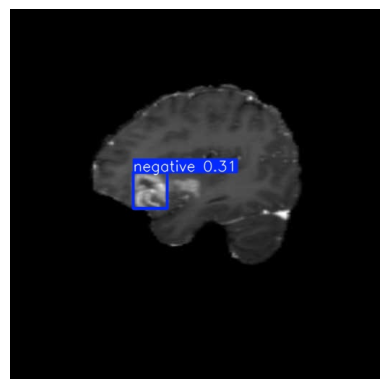

In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Ruta de la imagen (copiar de la carpeta de directorios)
path_to_image = "/content/runs/detect/predict/val_1 (1).jpg"

# Cargar la imagen
img = mpimg.imread(path_to_image)

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Oculta los ejes
plt.show()

In [24]:
# Access the results
for result in prediction_results:
    xywh = result.boxes.xywh  # center-x, center-y, width, height
    xywhn = result.boxes.xywhn  # normalized
    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    xyxyn = result.boxes.xyxyn  # normalized
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    confs = result.boxes.conf  # confidence score of each box
print("center-x, center-y, width, height",xywh)
print("center-x, center-y, width, height - normalized",xywhn)
print("top-left-x, top-left-y, bottom-right-x, bottom-right-y", xyxy)
print("top-left-x, top-left-y, bottom-right-x, bottom-right-y - normalized", xyxyn)
print("confidence score of each box", confs)

center-x, center-y, width, height tensor([[194.5919, 251.2469,  51.3100,  51.8167],
        [193.9407, 250.4458,  52.0969,  50.2721]], device='cuda:0')
center-x, center-y, width, height - normalized tensor([[0.3801, 0.4907, 0.1002, 0.1012],
        [0.3788, 0.4892, 0.1018, 0.0982]], device='cuda:0')
top-left-x, top-left-y, bottom-right-x, bottom-right-y tensor([[168.9369, 225.3385, 220.2469, 277.1553],
        [167.8923, 225.3097, 219.9892, 275.5818]], device='cuda:0')
top-left-x, top-left-y, bottom-right-x, bottom-right-y - normalized tensor([[0.3300, 0.4401, 0.4302, 0.5413],
        [0.3279, 0.4401, 0.4297, 0.5382]], device='cuda:0')
confidence score of each box tensor([0.3199, 0.2806], device='cuda:0')


Probamos ahora con otra imagen que nos da Ultralytics en la web.

La imagen contiene un tumor:

<img align="left" src="https://github.com/user-attachments/assets/f44df643-3ffc-4f3c-a08d-c213a1f24abb" width="600">

Vemos si hemos sido capaces de detectarlo:

In [28]:
# Imagen proporcionada por Ultralytics
# Inferencia: Realizar predicción sobre una imagen de prueba
prediction_results = modelp.predict("https://ultralytics.com/assets/brain-tumor-sample.jpg", save=True)


Found https://ultralytics.com/assets/brain-tumor-sample.jpg locally at brain-tumor-sample.jpg
image 1/1 /content/brain-tumor-sample.jpg: 640x640 1 positive, 16.8ms
Speed: 3.0ms preprocess, 16.8ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


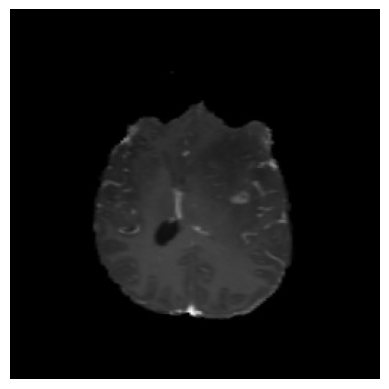

In [13]:
# Ruta de la imagen (copiar de la carpeta de directorios)
path_to_image = "/content/runs/detect/predict/brain-tumor-sample.jpg"

# Cargar la imagen
img = mpimg.imread(path_to_image)

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Oculta los ejes
plt.show()

## 9. Aumentado el dataset

El aumento de datos es una técnica crucial en visión artificial que expande artificialmente el conjunto de datos de entrenamiento mediante la aplicación de diversas transformaciones a imágenes existentes.

Con augmentacion de datos el modelo ve miles de variaciones y sin ellas el modelo ve siempre las mismas imágenes.

Al entrenar modelos de aprendizaje profundo como Ultralytics YOLO, el aumento de datos ayuda a mejorar la robustez del modelo, reduce el sobreajuste y optimiza la generalización a escenarios del mundo real.

Revisamos [YOLO Data Augmentation](https://docs.ultralytics.com/guides/yolo-data-augmentation/#example-configurations) y lo utilizamos para mejorar el funcionamiento de nuestro modelo

Aplicamos las siguientes transformaciones de aumento de imagenes:
* Rotación activa (±10°)
* Flip horizontal (50%)

Con `auto-augment` a `None` habilitamos las transformaciones solo en el entrenamiento, no en la infenrecia o prediccion.

In [27]:
# Training with custom augmentation parameters
# Cargar un modelo base de tamaño nano (se recomienda usar un modelo pre-entrenado para hacer ajuste fino)
model = YOLO("yolo26n.pt")

# Training without any augmentations (disabled values omitted for clarity)
results = model.train(
    data="brain-tumor.yaml",
    epochs=100, # Número de veces que el modelo ve todo el dataset, más aprendizaje (pero riesgo de overfitting)
    imgsz=640, # Tamaño de la imagen de entrada (640x640)
    hsv_h=0.0, # Parámetros de augmentación - Color (HSV) - tono (color) - 0.0 desactivado
    hsv_s=0.0, # Parámetros de augmentación - Color (HSV) - saturación - 0.0 desactivado
    hsv_v=0.0, # Parámetros de augmentación - Color (HSV) - saturación - 0.0 desactivado
    degrees=10.0, # Parámetros de augmentación - Rotación - 0.0 desactivado
    translate=0.0, # Parámetros de augmentación - mueve la imagen (shift) - 0.0 desactivado
    scale=0.0, # Parámetros de augmentación - zoom in/out - 0.0 desactivado
    fliplr=0.5, # Parámetros de augmentación - Flip horizontal - 0.0 desactivado
    mosaic=0.0, # Parámetros de augmentación - Mosaic - Combina 4 imágenes en una - 0.0 desactivado
    erasing=0.0, # Parámetros de augmentación - Borra partes aleatorias de la imagen - 0.0 desactivado
    auto_augment= None, # Técnicas automáticas tipo: 'randaugment', 'autoaugment', 'augmix', None
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train-8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

Vemos si ahora detecta el tumor

In [29]:
# Imagen proporcionada por Ultralytics
# Inferencia: Realizar predicción sobre una imagen de prueba
prediction_results = modelp.predict("https://ultralytics.com/assets/brain-tumor-sample.jpg", save=True)


Found https://ultralytics.com/assets/brain-tumor-sample.jpg locally at brain-tumor-sample.jpg
image 1/1 /content/brain-tumor-sample.jpg: 640x640 1 positive, 14.4ms
Speed: 3.6ms preprocess, 14.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


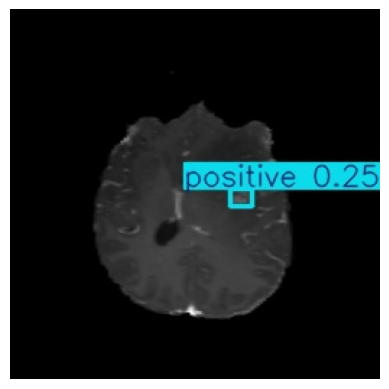

In [30]:

# Ruta de la imagen (copiar de la carpeta de directorios)
path_to_image = "/content/runs/detect/predict-2/brain-tumor-sample.jpg"

# Cargar la imagen
img = mpimg.imread(path_to_image)

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Oculta los ejes
plt.show()

## 10. Exportación del Modelo (*Export*)

Para llevar esta IA desde el laboratorio a la práctica clínica real (producción), necesitamos exportar el modelo a un formato compatible con los servidores del hospital, dispositivos móviles o equipos médicos integrados.

YOLO facilita la exportación a multitud de formatos (ONNX, TensorRT, CoreML, etc.) para optimizar la velocidad y el consumo de recursos.

Exploramos los modos de exportación que soporta [YOLO Model Export](https://docs.ultralytics.com/modes/export/)

A continuación, exportamos nuestro modelo entrenado al formato estándar de la industria, **ONNX**.

In [ ]:
from ultralytics import YOLO

# Cargar el modelo entrenado
modele = YOLO(f"{model.trainer.save_dir}/weights/best.pt")

# Exportar el modelo al formato ONNX (Open Neural Network Exchange)
modele.export(format="onnx")

Ultralytics 8.3.57 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO26n summary (fused): 238 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.46...
ONNX: export success ✅ 1.5s, saved as '/content/runs/detect/train/weights/best.onnx' (10.1 MB)

Export complete (2.2s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=640 data=/usr/local/lib/python3.10/dist-packages/ultralytics/cfg/datasets/brain-tumor.yaml  
Visualize:       https://netron.app


'/content/runs/detect/train/weights/best.onnx'

## 11. Conclusiones y Resultados

Tras completar este ciclo de desarrollo de IA en salud, extraemos las siguientes conclusiones clave:

1. **Viabilidad Técnica:** Hemos demostrado que, con el uso de herramientas modernas como **YOLO de Ultralytics**, la creación de modelos de detección médica de alta precisión es rápida y altamente factible, reduciendo la barrera de entrada tecnológica.
2. **Impacto Operativo:** Modelos como el que hemos entrenado aquí son capaces de procesar imágenes radiológicas en **milisegundos** (inferencia en tiempo real), ofreciendo una herramienta de segunda opinión vital y casi instantánea para el equipo médico.
3. **Resultados Alcanzados:** Se ha entrenado con éxito una red neuronal capaz de discriminar entre imágenes sanas y patológicas, y localizar espacialmente la anomalía. Aunque para un entorno de producción hospitalario real requeriríamos miles de imágenes más, validaciones clínicas exhaustivas y cumplimiento regulatorio estricto (CE/FDA), este ejercicio valida perfectamente el concepto fundacional.
4. **El Futuro de la IA Clínica:** La integración de estos algoritmos en los flujos de trabajo diarios de radiología promete una mayor eficiencia operativa, menos retrasos en los diagnósticos críticos y, en última instancia, una notable mejora en la calidad de la atención al paciente.

## 12. Citas y Referencias

Agradecimientos al equipo de Ultralytics por proporcionar el conjunto de datos de muestra y el entorno tecnológico.

```bibtex
@dataset{Jocher_Ultralytics_Datasets_2024,
    author = {Jocher, Glenn and Rizwan, Muhammad},
    license = {AGPL-3.0},
    month = {March},
    title = {Ultralytics Datasets:Brain-tumor Detection Dataset},
    url = {https://docs.ultralytics.com/datasets/detect/brain-tumor/},
    version = {1.0.0},
    year = {2024}
}
```